# Using U-TRACK dynamical decoupling sequences in Qiskit

This notebook shows how to load a ready-made U-TRACK sequence from the `Ready Sequences` folder of this repo and use it to build Qiskit circuits.

**Background:** Unlike periodic sequences such as XY4 (which repeat a short pulse block, e.g. `[0, pi/2, 0, pi/2]`, over and over), a U-TRACK sequence is a single, non-repeating list of pulse phases. Every `pi`-pulse in the sequence uses a phase optimized for its specific position, so the list *extends* rather than *cycles* as you add more pulses/blocks. This lets residual errors from earlier pulses be compensated by later ones, instead of accumulating the way they do under a purely periodic sequence.

This notebook covers:
1. Loading a sequence file (`.mat`) exported by `UTrack.jl`
2. Building Qiskit circuits that apply a prefix of the sequence (useful for benchmarking accumulated error vs. pulse count)
3. Converting a `.mat` sequence file to `.csv`, if you'd rather work with plain text

In [4]:
import re

import numpy as np
import pandas as pd
from scipy.io import loadmat

from qiskit import QuantumCircuit
from qiskit.circuit.library import RGate

## 1. Loading a U-TRACK sequence

Files in `ready sequences/` are named `UT{block_length}x{n_blocks}.mat`, e.g. `UT4x100.mat` is a U-TRACK4 sequence (4 phases per block) with 100 blocks, i.e. 400 total `pi`-pulses. Each file contains a single variable `phi`: a flat list of pulse phases (in radians). All pulses are $\pi$-rotations — only the phase varies from pulse to pulse.

The loader below reads the phase list for different block lengths.

In [6]:
def load_utrack_sequence(path):
    """Load a U-TRACK phase sequence from a .mat file.

    Parameters
    ----------
    path : str
        Path to a .mat file containing a 'phi' variable (as exported by UTrack.jl).

    Returns
    -------
    phases : np.ndarray
        1D array of pulse phases, in radians.
    block_length : int or None
        Number of phases per block, inferred from the filename (e.g. 4 for 'UT4x100.mat').
        None if the filename doesn't match the 'UT{block}x{n_blocks}' convention.
    n_blocks : int or None
        Number of blocks, inferred from the filename. None if not inferable.
    """
    phases = loadmat(path)["phi"].flatten()

    match = re.search(r"UT(\d+)x(\d+)", path)
    if match:
        block_length, n_blocks = int(match.group(1)), int(match.group(2))
        expected_len = block_length * n_blocks
        if expected_len != len(phases):
            print(
                f"Warning: filename implies {expected_len} phases "
                f"({block_length} x {n_blocks}), but file contains {len(phases)}."
            )
    else:
        block_length, n_blocks = None, None

    return phases, block_length, n_blocks


# Example: load a U-TRACK4 sequence with 100 blocks (400 pulses total)
phases, block_length, n_blocks = load_utrack_sequence("../Ready Sequences/UT4x100.mat")
print(f"Loaded {len(phases)} phases (block length = {block_length}, blocks = {n_blocks})")
print(phases[:8], "...")

Loaded 400 phases (block length = 4, blocks = 100)
[ 0.64973751 -4.07497942  0.495506    2.0574324  -0.96047024  2.0122031
  1.76670816 -1.21154074] ...


## 2. Building circuits from the sequence

A common use case is to sweep the number of applied blocks and see how a metric of interest (e.g. state fidelity) evolves as more pulses are applied — for instance to compare error accumulation between U-TRACK and a periodic sequence like XY4.

`build_dd_circuits` below builds one circuit per block boundary: 0 pulses, then the first block, then the first two blocks, and so on, up to the full sequence.

Built 101 circuits, from 0 to 400 pulses


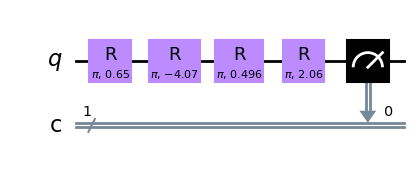

In [9]:
def build_dd_circuits(phases, block_length, n_blocks):
    """Build a family of 1-qubit circuits applying an increasing prefix of a DD sequence.

    Circuit j applies the first j full blocks of the sequence (j = 0, ..., n_blocks),
    i.e. j * block_length pulses in total, each a pi-rotation with the corresponding
    U-TRACK phase.

    Parameters
    ----------
    phases : array-like
        Full list of pulse phases, length >= block_length * n_blocks.
    block_length : int
        Number of phases per block (e.g. 4 for U-TRACK4).
    n_blocks : int
        Number of blocks to sweep over.

    Returns
    -------
    list[QuantumCircuit]
        Circuits with 0, 1, ..., n_blocks blocks applied (n_blocks + 1 circuits total).
    """
    circuits = []
    for n_pulses in range(0, block_length * n_blocks + 1, block_length):
        qc = QuantumCircuit(1, 1)
        for i in range(n_pulses):
            qc.append(RGate(np.pi, phases[i]), [0])
        qc.measure(0, 0)
        circuits.append(qc)
    return circuits


circuits = build_dd_circuits(phases, block_length, n_blocks)
print(f"Built {len(circuits)} circuits, from 0 to {block_length * n_blocks} pulses")

# Preview the circuit after the first block (4 pulses)
circuits[1].draw("mpl")

### Using U-TRACK sequences with Qiskit's `PadDynamicalDecoupling`

Qiskit's built-in [`PadDynamicalDecoupling`](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.transpiler.passes.PadDynamicalDecoupling) transpiler pass accepts a custom `dd_sequence` of gates and inserts it automatically into scheduled idle periods. It was designed with short, *periodic* sequences in mind (e.g. `[XGate(), XGate()]`), so a non-cyclic sequence like U-TRACK needs a small adaptation: pass the **full, fixed-length phase list** you want inserted as `dd_sequence`, rather than a short block meant to repeat, e.g.:

```python
from qiskit.transpiler.passes import PadDynamicalDecoupling

dd_sequence = [RGate(np.pi, phi) for phi in phases[:block_length * n_blocks]]
pad_dd = PadDynamicalDecoupling(durations, dd_sequence, qubits=[0])
```

Note that this only works cleanly if the idle window is long enough to fit the *entire* sequence — the pass won't cycle a shorter block to fill arbitrary idle time the way it does for periodic sequences. If you need the sequence to adapt to varying idle-time lengths, consider selecting a prefix of `phases` sized to fit each idle window (similar to what `build_dd_circuits` does above), or inserting the gates manually as in Section 2.

## 3. Converting a sequence file to CSV

If you'd rather work with the phase list outside MATLAB/Julia (e.g. in a spreadsheet or a language without a `.mat` reader), you can export it to plain CSV.

In [13]:
def mat_to_csv(mat_path, csv_path):
    """Convert the main variable of a .mat file to a single-column CSV file."""
    mat_data = loadmat(mat_path)
    key = [k for k in mat_data if not k.startswith("__")][0]  # first non-metadata variable
    arr = mat_data[key]
    pd.DataFrame(arr.flatten()).to_csv(csv_path, index=False, header=False)
    print(f"Saved '{key}' ({arr.size} values) from '{mat_path}' to '{csv_path}'")


mat_to_csv("../Ready Sequences/UT4x100.mat", "UT4x100.csv")

Saved 'phi' (400 values) from '../Ready Sequences/UT4x100.mat' to 'UT4x100.csv'
